# Descriptive Analysis of MSFT OHLC Data

aim is to understand the raw dataset

In [47]:
!pip install scipy

In [48]:
!pip install yfinance

In [49]:
!pip install matplotlib

In [50]:
!pip install seaborn

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_style('whitegrid')

In [52]:
ticker = 'MSFT'
start_date = '1999-01-01'
end_date = '2026-03-01'

target_horizon = 90
rolling_window = 30

In [53]:
def download_stock_data(ticker, start, end):
    df = yf.download(ticker, start = start, end=end, progress=False, auto_adjust=False)
    df = df.reset_index()
    return df

raw_df=download_stock_data(ticker, start_date, end_date)
raw_df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
0,1999-01-04,21.483637,35.25000,36.31250,34.843750,34.902344,69305200
1,1999-01-05,22.321653,36.62500,37.00000,35.359375,35.468750,64281600
2,1999-01-06,23.045399,37.81250,37.87500,36.687500,37.375000,69064800
3,1999-01-07,22.931118,37.62500,37.65625,37.062500,37.437500,51150400
4,1999-01-08,22.835892,37.46875,38.12500,36.750000,38.046875,50244800


In [54]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6830 entries, 0 to 6829
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   (Date, )           6830 non-null   datetime64[s]
 1   (Adj Close, MSFT)  6830 non-null   float64      
 2   (Close, MSFT)      6830 non-null   float64      
 3   (High, MSFT)       6830 non-null   float64      
 4   (Low, MSFT)        6830 non-null   float64      
 5   (Open, MSFT)       6830 non-null   float64      
 6   (Volume, MSFT)     6830 non-null   int64        
dtypes: datetime64[s](1), float64(5), int64(1)
memory usage: 373.6 KB


In [55]:
raw_df.describe()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
count,6830,6830.000000,6830.000000,6830.000000,6830.000000,6830.000000,6.830000e+03
mean,2012-07-29 23:25:25,98.265308,106.441849,107.465731,105.346423,106.431579,4.927130e+07
min,1999-01-04 00:00:00,11.113182,15.150000,15.620000,14.870000,15.200000,5.855900e+06
25%,2005-10-17 06:00:00,19.148659,27.440001,27.730000,27.180000,27.400000,2.660718e+07
50%,2012-07-28 12:00:00,26.199254,36.841875,37.254999,36.345001,36.872499,4.370470e+07
75%,2019-05-13 18:00:00,118.680241,126.175001,127.359999,124.772499,126.342499,6.357232e+07
max,2026-02-27 00:00:00,539.825195,542.070007,555.450012,540.770020,555.229980,5.910522e+08
std,NaN,130.843971,129.810409,130.921229,128.601277,129.820493,3.053143e+07


In [56]:
print("Dataset shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

print("\nDate range:")
print(raw_df["Date"].min(), "to", raw_df["Date"].max())

print("\nData types:")
print(raw_df.dtypes)

Dataset shape: (6830, 7)

Columns:
[('Date', ''), ('Adj Close', 'MSFT'), ('Close', 'MSFT'), ('High', 'MSFT'), ('Low', 'MSFT'), ('Open', 'MSFT'), ('Volume', 'MSFT')]

Date range:
1999-01-04 00:00:00 to 2026-02-27 00:00:00

Data types:
Price      Ticker
Date                 datetime64[s]
Adj Close  MSFT            float64
Close      MSFT            float64
High       MSFT            float64
Low        MSFT            float64
Open       MSFT            float64
Volume     MSFT              int64
dtype: object


In [57]:
# Flatten columns 
if isinstance(raw_df.columns, pd.MultiIndex):
    raw_df.columns = [
        "_".join([str(c) for c in col if c != ""]).strip()
        for col in raw_df.columns
    ]

raw_df.columns = [
    col.replace(f"_{ticker}", "") for col in raw_df.columns
]

raw_df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-04,21.483637,35.25000,36.31250,34.843750,34.902344,69305200
1,1999-01-05,22.321653,36.62500,37.00000,35.359375,35.468750,64281600
2,1999-01-06,23.045399,37.81250,37.87500,36.687500,37.375000,69064800
3,1999-01-07,22.931118,37.62500,37.65625,37.062500,37.437500,51150400
4,1999-01-08,22.835892,37.46875,38.12500,36.750000,38.046875,50244800


In [58]:
missing_summary = raw_df.isna().sum().to_frame(name="missing_count")
missing_summary["missing_percent"] = 100 * missing_summary["missing_count"] / len(raw_df)

duplicate_dates = raw_df["Date"].duplicated().sum()

print("Missing values:")
display(missing_summary)

print(f"\nNumber of duplicated dates: {duplicate_dates}")

Missing values:


,missing_count,missing_percent
Date,0,0.0
Adj Close,0,0.0
Close,0,0.0
High,0,0.0
Low,0,0.0
Open,0,0.0
Volume,0,0.0



Number of duplicated dates: 0


In [59]:
df = raw_df.copy()

df['daily_return'] = df['Close'].pct_change()           #percentage change from previous day
df['log_return'] = np.log(df['Close']/df['Close'].shift(1))     

df[f'rolling_mean_{rolling_window}D'] = df['Close'].rolling(window=rolling_window).mean()
df[f'rolling_volatility_{rolling_window}D'] = df['daily_return'].rolling(window=rolling_window).std()

df[f'future_close_{target_horizon}D'] = df['Close'].shift(-target_horizon)
df[f'target_{target_horizon}D'] = (df[f'future_close_{target_horizon}D']>df['Close']).astype(int)

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,daily_return,log_return,rolling_mean_30D,rolling_volatility_30D,future_close_90D,target_90D
0,1999-01-04,21.483637,35.25000,36.31250,34.843750,34.902344,69305200,NaN,NaN,NaN,NaN,39.56250,1
1,1999-01-05,22.321653,36.62500,37.00000,35.359375,35.468750,64281600,0.039007,0.038266,NaN,NaN,38.43750,1
2,1999-01-06,23.045399,37.81250,37.87500,36.687500,37.375000,69064800,0.032423,0.031909,NaN,NaN,39.56250,1
3,1999-01-07,22.931118,37.62500,37.65625,37.062500,37.437500,51150400,-0.004959,-0.004971,NaN,NaN,39.34375,1
4,1999-01-08,22.835892,37.46875,38.12500,36.750000,38.046875,50244800,-0.004153,-0.004161,NaN,NaN,39.65625,1


In [60]:
summary_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "Daily_Return", "Log_Return"]

available_summary_cols = [col for col in summary_cols if col in df.columns]

summary_stats = df[available_summary_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
Open,6830.0,1.064316e+02,1.298205e+02,1.520000e+01,2.740000e+01,3.687250e+01,1.263425e+02,5.552300e+02
High,6830.0,1.074657e+02,1.309212e+02,1.562000e+01,2.773000e+01,3.725500e+01,1.273600e+02,5.554500e+02
Low,6830.0,1.053464e+02,1.286013e+02,1.487000e+01,2.718000e+01,3.634500e+01,1.247725e+02,5.407700e+02
Close,6830.0,1.064418e+02,1.298104e+02,1.515000e+01,2.744000e+01,3.684188e+01,1.261750e+02,5.420700e+02
Adj Close,6830.0,9.826531e+01,1.308440e+02,1.111318e+01,1.914866e+01,2.619925e+01,1.186802e+02,5.398252e+02
Volume,6830.0,4.927130e+07,3.053143e+07,5.855900e+06,2.660718e+07,4.370470e+07,6.357232e+07,5.910522e+08


the data set spans 27 (1999-2026) years of dailty trading data, capturing multiple market regimes (dot-com era, 2008 crisis, COVID) and long term trands

no missing or duplicate values - data is clean and suitable for analysis without imputation

close min - 15 and close max is 542 => strong long term upward growth, non stationary nature

mean - 106 and median value is 36 => skewed distribution driven by recent high prices

trading volume variability: mean is 49M and Max is 541M => probably caused by market crashes, covid




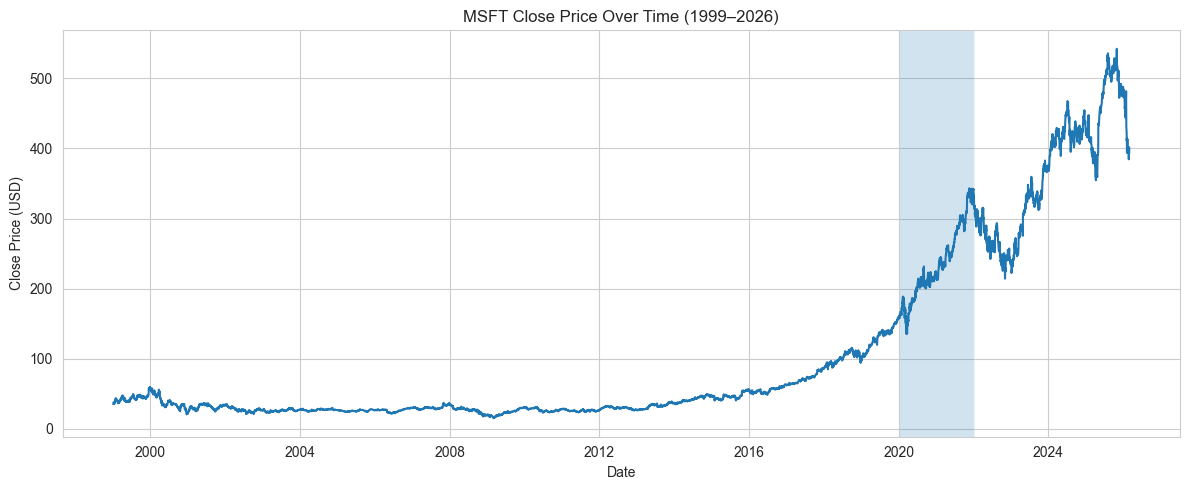

In [61]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])

plt.title("MSFT Close Price Over Time (1999–2026)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

# Optional: highlight COVID era
plt.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2022-01-01"), alpha=0.2)

plt.tight_layout()
plt.show()

1993 - 2013 : almost flat
2014 onword : steep acceleration
2020 onward : fast growth

clear non linear, approximately exponential growth, especially after 2014 => linear models insufficient for capturing long term trends

Non-stationarity: 
- mean changes over time
- variance increases over time
trend and volatility is evolving significantly

1999-2013 : flat or slow growth, low volatility
2014-2019 : steady growth, moderate volatility
2020 onwards : rapid increase, high volatility (COVID + tech boom)

period of volatility is clustered => typical of financial time series

this tells us that raw prices are bad features, the scale changes over time

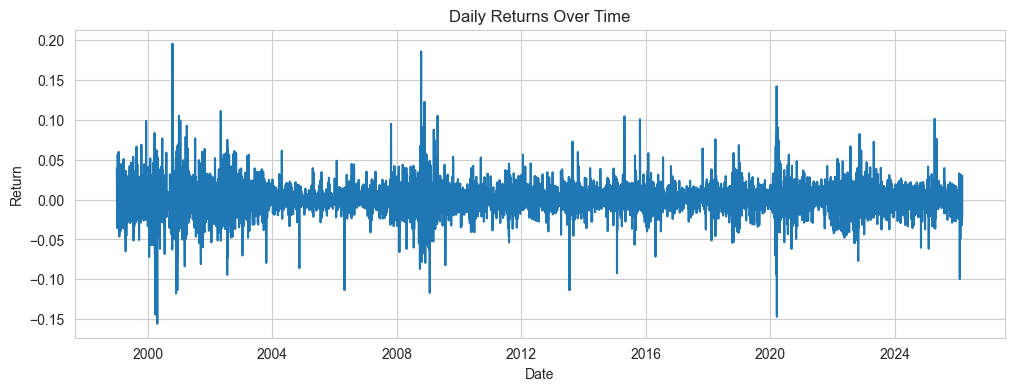

In [62]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["daily_return"])
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

daily returns fluctuate around 0
occasional extreme spikes, volatility clustering (large spikes come in clusters)

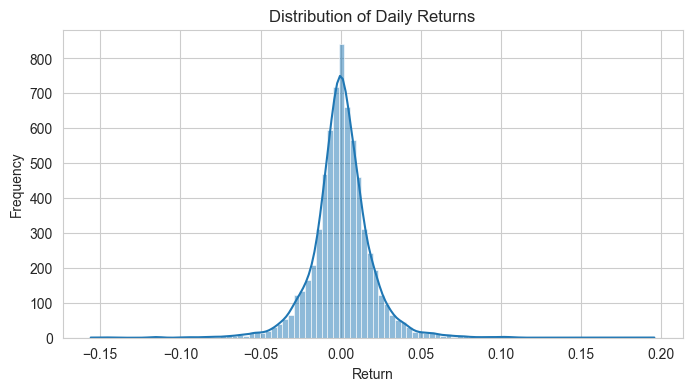

In [63]:
plt.figure(figsize=(8, 4))
sns.histplot(df["daily_return"].dropna(), bins=100, kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

looks gaussian because centered at 0, roughly symmetric
but very sharp peak and very heavy tails - **this is called a leptokurtic distribution**

the returns vary between about +/- 15-20 %, a lot more than what a normal distribution would do => extreme events happen more often than expected

sharp peak at 0 => mostly market is quiet but sometimes crazy things happen

almost symmetric 

In [64]:
# computing skewness

from scipy.stats import skew, kurtosis

returns = df['daily_return'].dropna()
print('skewness:', skew(returns))
print('kurtosis: ', kurtosis(returns))

skewness: 0.17783310913115957
kurtosis:  8.936146941788436


skewness is slightly positive but close to 0 => distribution is almost symmetric but slightly skewed towards positive return (long term growth)

kurtosis is 0 for normal distributions, for us its 8.94 => extremely heavy tails, peaks at the centre => returns are far from gaussian

gaussian assumption is insufficient so more flexible ML approaches required



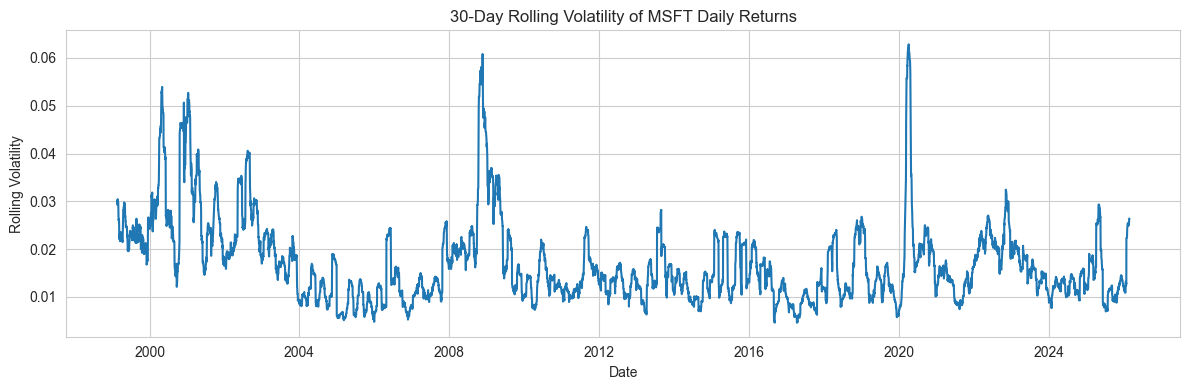

In [65]:
# rolling volatility plot for daily returns
plt.figure(figsize=(12, 4))

plt.plot(df["Date"][30:], df[f"rolling_volatility_{rolling_window}D"][30:])

plt.title(f"{rolling_window}-Day Rolling Volatility of MSFT Daily Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.tight_layout()
plt.show()

In [66]:
target_col = f"target_{target_horizon}D"

class_counts = df[target_col].value_counts(dropna=True)
class_percent = df[target_col].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

Class counts:
target_90D
1    4187
0    2643
Name: count, dtype: int64

Class percentages:
target_90D
1    61.303075
0    38.696925
Name: proportion, dtype: float64


In [67]:

df[f"future_close_{target_horizon}D"] = df["Close"].shift(-target_horizon)

df[f"target_{target_horizon}D"] = np.where(
    df[f"future_close_{target_horizon}D"].notna(),
    (df[f"future_close_{target_horizon}D"] > df["Close"]).astype(int),
    np.nan
)

target_col = f"target_{target_horizon}D"

class_counts = df[target_col].value_counts(dropna=True)
class_percent = df[target_col].value_counts(normalize=True, dropna=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

Class counts:
target_90D
1.0    4187
0.0    2553
Name: count, dtype: int64

Class percentages:
target_90D
1.0    62.121662
0.0    37.878338
Name: proportion, dtype: float64


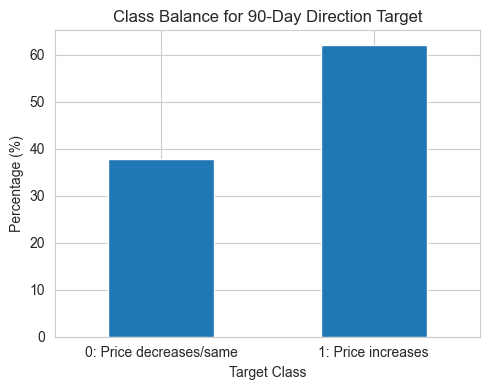

In [68]:
plt.figure(figsize=(5, 4))

class_percent.sort_index().plot(kind="bar")

plt.title("Class Balance for 90-Day Direction Target")
plt.xlabel("Target Class")
plt.ylabel("Percentage (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["0: Price decreases/same", "1: Price increases"],
    rotation=0
)

plt.tight_layout()
plt.show()

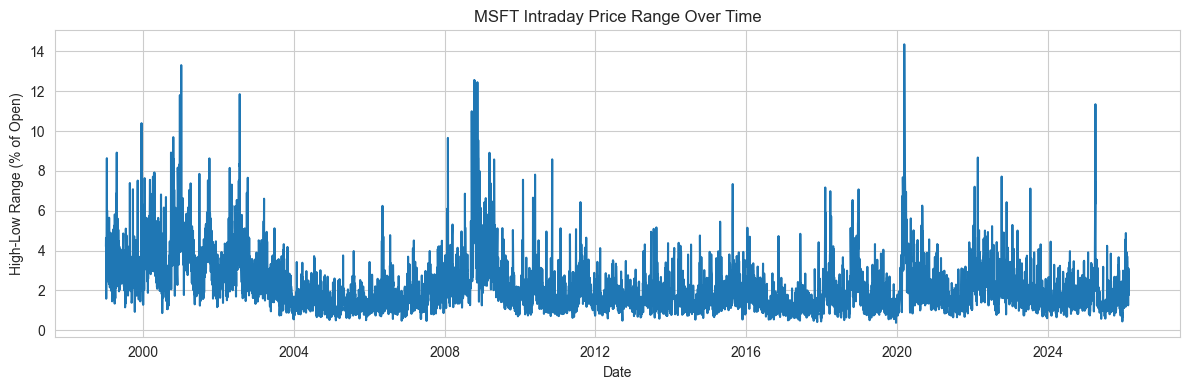

In [69]:
# intraday price range/uncertainty

df["intraday_range"] = df["High"] - df["Low"]
df["intraday_range_pct"] = (df["High"] - df["Low"]) / df["Open"] * 100

plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["intraday_range_pct"])

plt.title("MSFT Intraday Price Range Over Time")
plt.xlabel("Date")
plt.ylabel("High-Low Range (% of Open)")

plt.tight_layout()
plt.show()

Large spikes:
~2000 (dot-com)
~2008 (financial crisis)
~2020 (COVID — biggest spike ~14%)

clustering of spikes visible - volatility
these spikes indicat ehightened periods of uncertainty

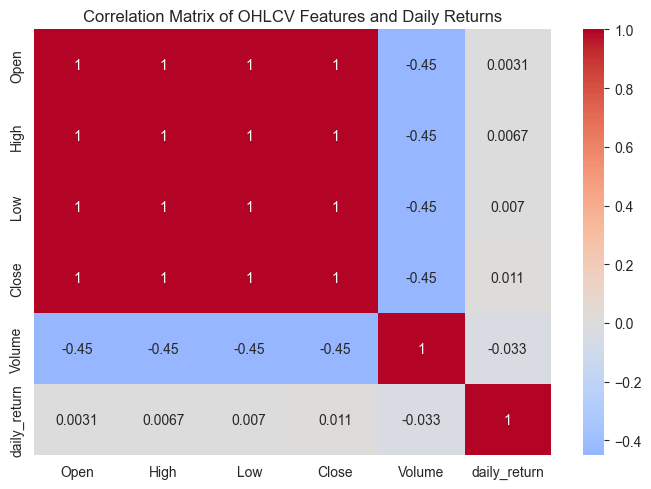

In [70]:
# correlaation heatmap

ohlcv_cols = ["Open", "High", "Low", "Close", "Volume", "daily_return"]

corr = df[ohlcv_cols].dropna().corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Matrix of OHLCV Features and Daily Returns")
plt.tight_layout()
plt.show()

OHLC completly correlated => redundancy in raw price data

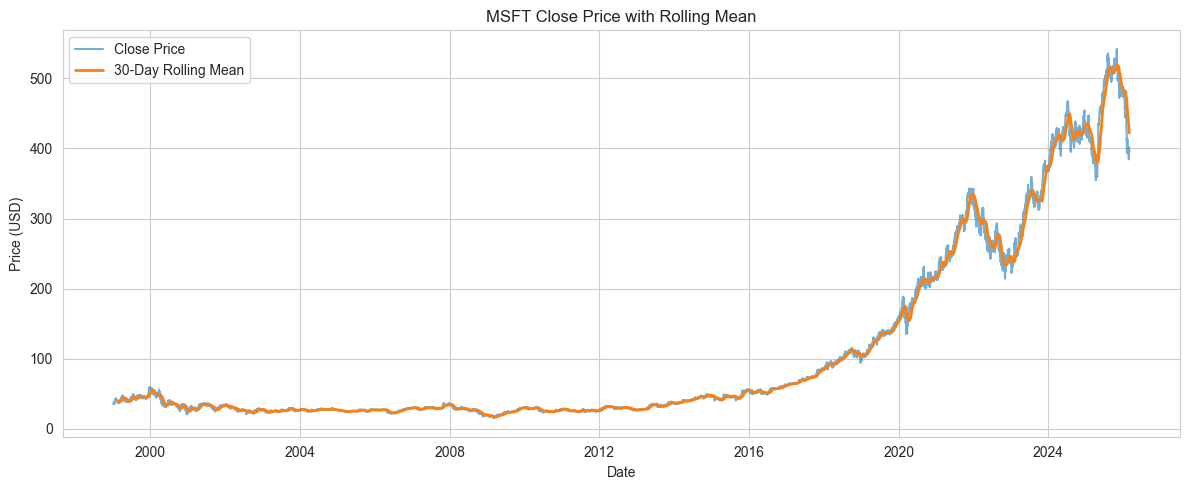

In [71]:
rolling_mean_col = f"rolling_mean_{rolling_window}D"

plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"], label="Close Price", alpha=0.6)
plt.plot(df["Date"], df[rolling_mean_col], label=f"{rolling_window}-Day Rolling Mean", linewidth=2)

plt.title("MSFT Close Price with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.tight_layout()
plt.show()

rolling mean has smoothened the noise.
divergence increases later => volatile

# plots for report

In [72]:
df.columns.tolist()

['Date',
 'Adj Close',
 'Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'daily_return',
 'log_return',
 'rolling_mean_30D',
 'rolling_volatility_30D',
 'future_close_90D',
 'target_90D',
 'intraday_range',
 'intraday_range_pct']

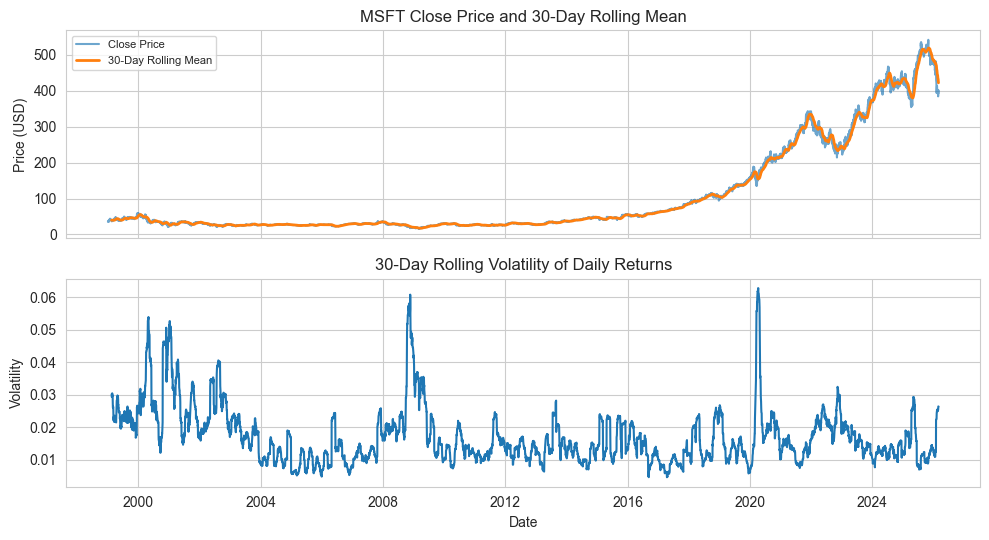

In [81]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

# Close price + rolling mean
axes[0].plot(df["Date"], df["Close"], label="Close Price", alpha=0.65)
axes[0].plot(df["Date"], df["rolling_mean_30D"], label="30-Day Rolling Mean", linewidth=2)
axes[0].set_title("MSFT Close Price and 30-Day Rolling Mean")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(fontsize=8)

# Rolling volatility
axes[1].plot(df["Date"], df["rolling_volatility_30D"])
axes[1].set_title("30-Day Rolling Volatility of Daily Returns")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Volatility")

plt.tight_layout()
fig.savefig("msft_price_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

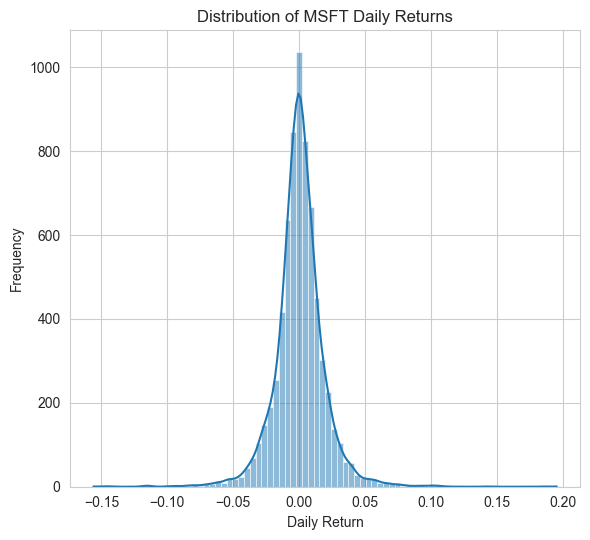

In [84]:
returns = df["daily_return"].dropna()

fig, ax = plt.subplots(figsize=(6, 5.5))

sns.histplot(
    returns,
    bins=80,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of MSFT Daily Returns")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")

plt.tight_layout()
fig.savefig("msft_return_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

precision recall accuracy f1 score roc curve
2 models - backtesting
1 is validation

include a table of the optimised hyperparameters
table containing the results
plots showing the results
